Hier feature engineering un einen gemeinsamen train Datensatz für die Modellierung
- Zielvariable: sales (nur im Train‑Set)

- Extrahiere einen Val Datensatz (die letzten 2 Wochen, z.B.)

- Features:

--Zeitfeatures (Tag, Monat, Wochentag, is_weekend, etc.)

--Store‑Features (Typ, State, Cluster … aus stores)

--Feiertags‑Features (aus holidays_events – zunächst einfache Flags)

--Ölpreis (dcoilwtico ohne Missing Values)

--Transaktionen (transactions)


In [134]:
from pathlib import Path
import pandas as pd
import numpy as np

In [135]:
BASE_DIR = Path(r"C:\Users\nelid\Documents\Kaggle Competitions\Store Sales Competition\store-sales")
PROCESSED_DIR = BASE_DIR / "data" / "processed"

files_processed = {
    "train": "train_processed.csv",
    "test": "test_processed.csv",
    "stores": "stores_processed.csv",
    "oil": "oil_processed.csv",
    "holidays_events": "holidays_events_processed.csv",
    "transactions": "transactions_processed.csv",
}

In [136]:
dfs = {}
for name, fname in files_processed.items():
    path = PROCESSED_DIR / fname
    df = pd.read_csv(path, parse_dates=["date"]) if "date" in pd.read_csv(path, nrows=1).columns else pd.read_csv(path)
    dfs[name] = df
    print(f"{name}: shape={df.shape}, date dtype={dfs[name]['date'].dtype if 'date' in df.columns else 'no date column'}")
    print(f"{name}: summary={df.info()} ")

train: shape=(3000888, 6), date dtype=datetime64[ns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB
train: summary=None 
test: shape=(28512, 5), date dtype=datetime64[ns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28512 entries, 0 to 28511
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           28512 non-null  int64         
 1   date         28512 non-null  datetime64[ns]
 2   store_nbr    28512 non-null  int64         
 3   family       28512 non-null  object        
 4   onpromotio

In [137]:
dfs["holidays_events"].head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [138]:
## Erstelle Zeit-Features auf train /test Datensatz. Feiertage später

def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["dayofweek"] = df["date"].dt.dayofweek  # 0=Montag
    df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)
    df["dayofyear"] = df["date"].dt.dayofyear
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    return df

train_fe = add_time_features(dfs["train"])
test_fe = add_time_features(dfs["test"])


In [139]:
train_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 13 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
 6   year         int32         
 7   month        int32         
 8   day          int32         
 9   dayofweek    int32         
 10  weekofyear   int64         
 11  dayofyear    int32         
 12  is_weekend   int64         
dtypes: datetime64[ns](1), float64(1), int32(5), int64(5), object(1)
memory usage: 240.4+ MB


In [140]:
train_fe.head(20)

,id,date,store_nbr,family,sales,onpromotion,year,month,day,dayofweek,weekofyear,dayofyear,is_weekend
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,2013,1,1,1,1,1,0
1,1,2013-01-01,1,BABY CARE,0.0,0,2013,1,1,1,1,1,0
2,2,2013-01-01,1,BEAUTY,0.0,0,2013,1,1,1,1,1,0
3,3,2013-01-01,1,BEVERAGES,0.0,0,2013,1,1,1,1,1,0
4,4,2013-01-01,1,BOOKS,0.0,0,2013,1,1,1,1,1,0
5,5,2013-01-01,1,BREAD/BAKERY,0.0,0,2013,1,1,1,1,1,0
6,6,2013-01-01,1,CELEBRATION,0.0,0,2013,1,1,1,1,1,0
7,7,2013-01-01,1,CLEANING,0.0,0,2013,1,1,1,1,1,0
8,8,2013-01-01,1,DAIRY,0.0,0,2013,1,1,1,1,1,0
9,9,2013-01-01,1,DELI,0.0,0,2013,1,1,1,1,1,0


In [141]:
## Mergen der Öl-Daten

train_fe = train_fe.merge(dfs["stores"], on="store_nbr", how="left")
test_fe = test_fe.merge(dfs["stores"], on="store_nbr", how="left")


In [142]:
train_fe.head(5)

,id,date,store_nbr,family,sales,onpromotion,year,month,day,dayofweek,weekofyear,dayofyear,is_weekend,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,2013,1,1,1,1,1,0,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,2013,1,1,1,1,1,0,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0,2013,1,1,1,1,1,0,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.0,0,2013,1,1,1,1,1,0,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.0,0,2013,1,1,1,1,1,0,Quito,Pichincha,D,13


In [143]:
train_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 17 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
 6   year         int32         
 7   month        int32         
 8   day          int32         
 9   dayofweek    int32         
 10  weekofyear   int64         
 11  dayofyear    int32         
 12  is_weekend   int64         
 13  city         object        
 14  state        object        
 15  type         object        
 16  cluster      int64         
dtypes: datetime64[ns](1), float64(1), int32(5), int64(6), object(4)
memory usage: 332.0+ MB


In [144]:
## Transaktionen mergen
## Transaktionsdaten sind auf Ebene (date, store_nbr) und geben zusätzliche Information zur Nachfrage.


train_fe = train_fe.merge(dfs["transactions"], on=["date", "store_nbr"], how="left")
test_fe = test_fe.merge(dfs["transactions"], on=["date", "store_nbr"], how="left")

train_fe["transactions"] = train_fe["transactions"].fillna(0)
test_fe["transactions"] = test_fe["transactions"].fillna(0)


In [145]:
 train_fe["transactions"].describe()

count    3.000888e+06
mean     1.555808e+03
std      1.033367e+03
min      0.000000e+00
25%      9.300000e+02
50%      1.331000e+03
75%      1.976250e+03
max      8.359000e+03
Name: transactions, dtype: float64

In [146]:
## Grundlage des Modellierungs-Datensatzes speichern

train_fe.to_csv(PROCESSED_DIR / "train_model_base.csv", index=False)
test_fe.to_csv(PROCESSED_DIR / "test_model_base.csv", index=False)


In [147]:
### Hier systematische Untersuchung der Effekte über die Zeit

# Beispiel: ein Store + eine Family
ex = train_fe[(train_fe["store_nbr"] == 1) & (train_fe["family"] == "GROCERY I")].copy()
ex = ex.sort_values("date")
ex_ts = ex.set_index("date")["sales"]


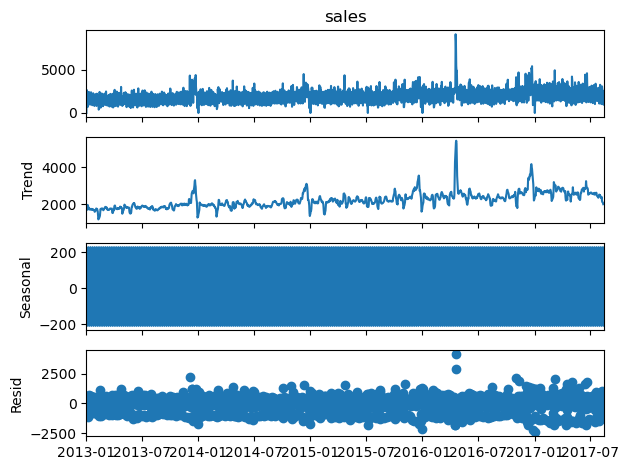

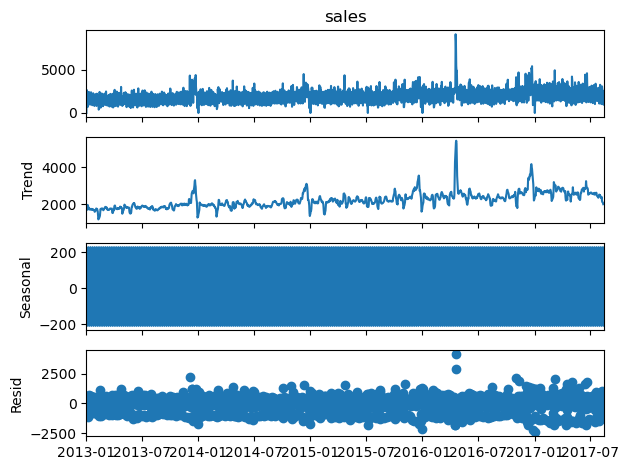

In [148]:
## Trend und Saisonalität untersuchen

from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(ex_ts, model="additive", period=7)  # wöchentliche Saisonalität
result.plot()


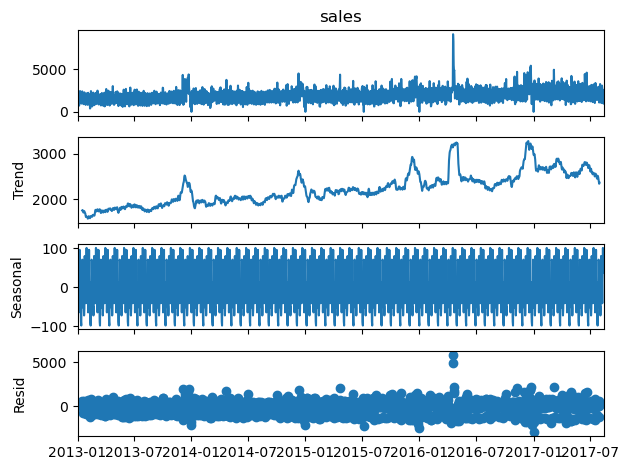

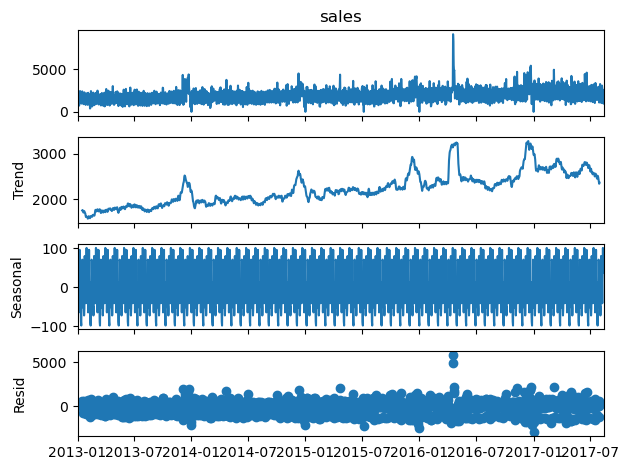

In [149]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(ex_ts, model="additive", period=30)  # monatliche Saisonalität
result.plot()


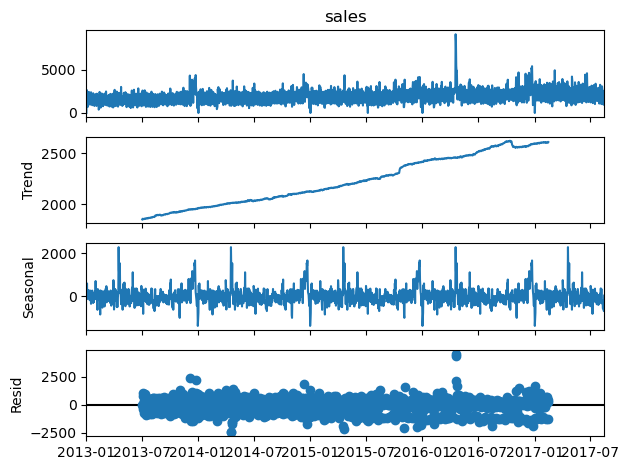

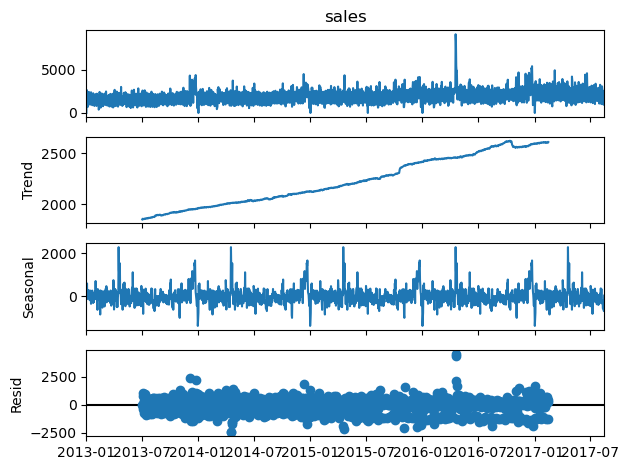

In [150]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(ex_ts, model="additive", period=365)  # jährliche Saisonalität
result.plot()


<Figure size 1000x400 with 0 Axes>

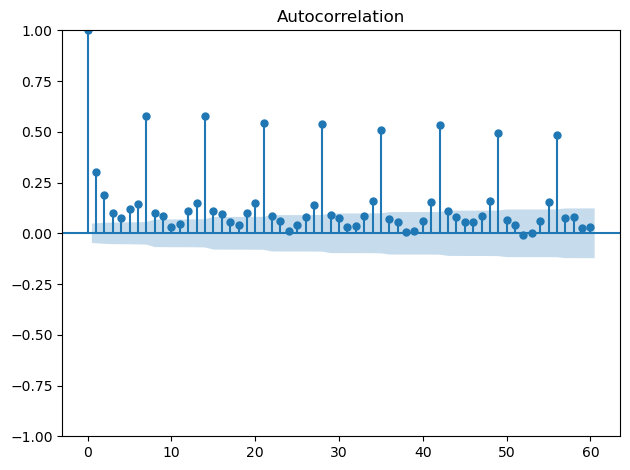

<Figure size 1000x400 with 0 Axes>

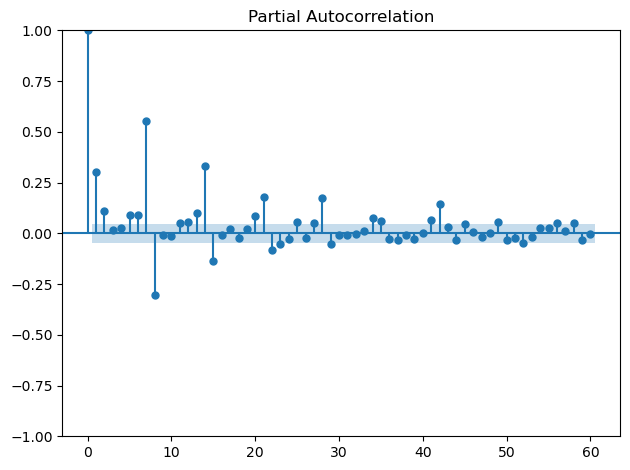

In [151]:
### ACF und PACF

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plot_acf(ex_ts, lags=60)
plt.tight_layout()

plt.figure(figsize=(10, 4))
plot_pacf(ex_ts, lags=60, method="ywm")
plt.tight_layout()


In [152]:
## Weitere Zeit-Features: Lags und Rolling-Means pro store/family

## Wichtig: Sortierung nach store, family und date. Sonst stimmen die Lags nicht

train_fe = train_fe.sort_values(["store_nbr", "family", "date"])

In [153]:
import numpy as np

def add_lag_features(
    df: pd.DataFrame,
    group_cols: list[str],
    target_col: str = "sales",
    lags: list[int] = [1, 7, 14, 21, 28],
    rolling_windows: list[int] = [7, 14, 28, 56, 90],
) -> pd.DataFrame:
    df = df.copy()
    df = df.sort_values(group_cols + ["date"])

    # Lag-Features
    for lag in lags:
        df[f"{target_col}_lag_{lag}"] = (
            df.groupby(group_cols)[target_col].shift(lag)
        )

    # Rolling-Mean-Features
    for lag in lags:
        lag_col = f"{target_col}_lag_{lag}"
        for win in rolling_windows:
            df[f"{target_col}_rmean_lag{lag}_win{win}"] = (
                df.groupby(group_cols)[lag_col]
                  .transform(lambda s: s.rolling(window=win, min_periods=1).mean())
            )

    return df

train_all_lagged = add_lag_features(
    train_fe,
    group_cols=["store_nbr", "family"],
    target_col="sales",
    lags=[1, 7, 14, 21, 28],
    rolling_windows=[7, 14, 28, 56, 90],
)


In [154]:
train_all_lagged.head(5)

,id,date,store_nbr,family,sales,onpromotion,year,month,day,dayofweek,...,sales_rmean_lag21_win7,sales_rmean_lag21_win14,sales_rmean_lag21_win28,sales_rmean_lag21_win56,sales_rmean_lag21_win90,sales_rmean_lag28_win7,sales_rmean_lag28_win14,sales_rmean_lag28_win28,sales_rmean_lag28_win56,sales_rmean_lag28_win90
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,2013,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1782,1782,2013-01-02,1,AUTOMOTIVE,2.0,0,2013,1,2,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3564,3564,2013-01-03,1,AUTOMOTIVE,3.0,0,2013,1,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5346,5346,2013-01-04,1,AUTOMOTIVE,3.0,0,2013,1,4,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7128,7128,2013-01-05,1,AUTOMOTIVE,5.0,0,2013,1,5,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [155]:
## Hier Behandlung der Holiday-Angaben. Die Competition‑Beschreibung sagt explizit, 
## dass der tatsächlich gefeierte Tag auf der Transfer‑Zeile liegt und der ursprüngliche Tag wie ein normaler Tag behandelt werden soll.
hol = dfs["holidays_events"].copy()

hol = add_time_features(hol)

# ursprüngliche (verschobene) Holidays
original = hol[(hol["transferred"] == True) & (hol["type"] != "Transfer")][
    ["description", "date"]
].rename(columns={"date": "original_date"})

# Zeilen mit type == "Transfer" (tatsächlicher Feiertag)
transfer = hol[hol["type"] == "Transfer"][["description", "date"]].rename(
    columns={"date": "observed_date"}
)

transfer_map = pd.merge(transfer, original, on="description", how="left")
observed_dates = transfer_map["observed_date"].dropna().unique()

In [156]:
#  Flags pro Holiday-Typ

hol["is_additional_holiday"] = (hol["type"] == "Additional").astype(int)
hol["is_bridge_day"] = (hol["type"] == "Bridge").astype(int)
hol["is_work_day_comp"] = (hol["type"] == "Work Day").astype(int)
hol["is_transfer_row"] = (hol["type"] == "Transfer").astype(int)
hol["is_transferred_flag"] = hol["transferred"].astype(int)


In [157]:
# „Observed Holiday“ pro Datum

hol["is_holiday_observed"] = 0

# 1) Tage mit Transfer-Typ (observed_date)
hol.loc[hol_feat["date"].isin(observed_dates), "is_holiday_observed"] = 1

# 2) „normale“ Feiertage ohne Transfer
non_transfer_holidays = hol[
    (hol["type"].isin(["Holiday", "Additional", "Bridge"])) &
    (hol["transferred"] == False)
]["date"].unique()

hol.loc[hol_feat["date"].isin(non_transfer_holidays), "is_holiday_observed"] = 1


In [158]:
hol["is_holiday_weekend"] = (
    (hol["is_holiday_observed"] == 1) &
    (hol["is_weekend"] == 1)
).astype(int)

In [159]:
# Auf Datumsebene aggregieren

agg_funcs = {
    "is_holiday_observed": "max",
    "is_additional_holiday": "max",
    "is_bridge_day": "max",
    "is_work_day_comp": "max",
    "is_transferred_flag": "max",
    "is_holiday_weekend": "max",
}

holiday_daily = (
    hol.groupby("date", as_index=False)
            .agg(agg_funcs)
            .sort_values("date")
)

# optional: Namen für spätere, komplexere Features
names_per_day = (
    hol.groupby("date")["description"]
       .apply(lambda x: ";".join(sorted(set(x.astype(str)))))
       .reset_index(name="holiday_names")
)

holiday_daily = holiday_daily.merge(names_per_day, on="date", how="left")
holiday_daily.to_csv(PROCESSED_DIR / "holiday_features_daily.csv", index=False)



In [160]:
holiday_daily.head()

,date,is_holiday_observed,is_additional_holiday,is_bridge_day,is_work_day_comp,is_transferred_flag,is_holiday_weekend,holiday_names
0,2012-03-02,1,0,0,0,0,0,Fundacion de Manta
1,2012-04-01,1,0,0,0,0,1,Provincializacion de Cotopaxi
2,2012-04-12,1,0,0,0,0,0,Fundacion de Cuenca
3,2012-04-14,1,0,0,0,0,1,Cantonizacion de Libertad
4,2012-04-21,1,0,0,0,0,1,Cantonizacion de Riobamba


In [161]:
hol.head()


,date,type,locale,locale_name,description,transferred,year,month,day,dayofweek,weekofyear,dayofyear,is_weekend,is_additional_holiday,is_bridge_day,is_work_day_comp,is_transfer_row,is_transferred_flag,is_holiday_observed,is_holiday_weekend
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False,2012,3,2,4,9,62,0,0,0,0,0,0,1,0
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False,2012,4,1,6,13,92,1,0,0,0,0,0,1,1
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False,2012,4,12,3,15,103,0,0,0,0,0,0,1,0
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False,2012,4,14,5,15,105,1,0,0,0,0,0,1,1
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False,2012,4,21,5,16,112,1,0,0,0,0,0,1,1


In [162]:
train_all_lagged.head()

,id,date,store_nbr,family,sales,onpromotion,year,month,day,dayofweek,...,sales_rmean_lag21_win7,sales_rmean_lag21_win14,sales_rmean_lag21_win28,sales_rmean_lag21_win56,sales_rmean_lag21_win90,sales_rmean_lag28_win7,sales_rmean_lag28_win14,sales_rmean_lag28_win28,sales_rmean_lag28_win56,sales_rmean_lag28_win90
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,2013,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1782,1782,2013-01-02,1,AUTOMOTIVE,2.0,0,2013,1,2,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3564,3564,2013-01-03,1,AUTOMOTIVE,3.0,0,2013,1,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5346,5346,2013-01-04,1,AUTOMOTIVE,3.0,0,2013,1,4,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7128,7128,2013-01-05,1,AUTOMOTIVE,5.0,0,2013,1,5,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [163]:
train_all_lagged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3000888 entries, 0 to 3000755
Data columns (total 48 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   id                       int64         
 1   date                     datetime64[ns]
 2   store_nbr                int64         
 3   family                   object        
 4   sales                    float64       
 5   onpromotion              int64         
 6   year                     int32         
 7   month                    int32         
 8   day                      int32         
 9   dayofweek                int32         
 10  weekofyear               int64         
 11  dayofyear                int32         
 12  is_weekend               int64         
 13  city                     object        
 14  state                    object        
 15  type                     object        
 16  cluster                  int64         
 17  transactions             float64

In [164]:
# Holiday-Features in Train/Val einbauen

holiday_daily = pd.read_csv(PROCESSED_DIR / "holiday_features_daily.csv", parse_dates=["date"])

for df_name in ["train_all_lagged"]:
    df = locals()[df_name]
    df = df.merge(holiday_daily, on="date", how="left").fillna(0)
    locals()[df_name] = df


In [165]:
holiday_daily.head(20)

,date,is_holiday_observed,is_additional_holiday,is_bridge_day,is_work_day_comp,is_transferred_flag,is_holiday_weekend,holiday_names
0,2012-03-02,1,0,0,0,0,0,Fundacion de Manta
1,2012-04-01,1,0,0,0,0,1,Provincializacion de Cotopaxi
2,2012-04-12,1,0,0,0,0,0,Fundacion de Cuenca
3,2012-04-14,1,0,0,0,0,1,Cantonizacion de Libertad
4,2012-04-21,1,0,0,0,0,1,Cantonizacion de Riobamba
5,2012-05-12,1,0,0,0,0,1,Cantonizacion del Puyo
6,2012-06-23,1,0,0,0,0,1,Cantonizacion de Guaranda
7,2012-06-25,1,0,0,0,0,0,Cantonizacion de Latacunga;Fundacion de Machal...
8,2012-07-03,1,0,0,0,0,0,Cantonizacion de El Carmen;Fundacion de Santo ...
9,2012-07-23,1,0,0,0,0,0,Cantonizacion de Cayambe


In [166]:
# Simple Level-Features

train_all_lagged["log_sales"] = np.log1p(train_all_lagged["sales"])
train_all_lagged["sales_per_transaction"] = train_all_lagged["sales"] / (train_all_lagged["transactions"] + 1)


In [167]:
train_all_lagged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 57 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   id                       int64         
 1   date                     datetime64[ns]
 2   store_nbr                int64         
 3   family                   object        
 4   sales                    float64       
 5   onpromotion              int64         
 6   year                     int32         
 7   month                    int32         
 8   day                      int32         
 9   dayofweek                int32         
 10  weekofyear               int64         
 11  dayofyear                int32         
 12  is_weekend               int64         
 13  city                     object        
 14  state                    object        
 15  type                     object        
 16  cluster                  int64         
 17  transactions             fl

In [168]:
## Abtrennen eines Val-Datensatzes mit 6 Wochen am Ende des Test-Datensatzes:

val_start = pd.Timestamp("2017-07-01")
val_end   = pd.Timestamp("2017-08-31")



In [169]:
#  Behandlung der NaNs in den Lag-Fatures - Ersetzung mit dem Median

lag_cols = [c for c in train_all_lagged.columns if "sales_lag_" in c]

# Median je Lag-Spalte berechnen (nur im Trainingszeitraum, nicht über Val/Test!)
lag_medians = train_all_lagged[lag_cols].median()

# In Train- und Val-Teil anwenden
train_part = train_all_lagged[train_all_lagged["date"] < val_start].copy()
val_part   = train_all_lagged[
    (train_all_lagged["date"] >= val_start) & (train_all_lagged["date"] <= val_end)
].copy()

train_part[lag_cols] = train_part[lag_cols].fillna(lag_medians)
val_part[lag_cols]   = val_part[lag_cols].fillna(lag_medians)


In [170]:
train_part.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2918916 entries, 0 to 3000841
Data columns (total 57 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   id                       int64         
 1   date                     datetime64[ns]
 2   store_nbr                int64         
 3   family                   object        
 4   sales                    float64       
 5   onpromotion              int64         
 6   year                     int32         
 7   month                    int32         
 8   day                      int32         
 9   dayofweek                int32         
 10  weekofyear               int64         
 11  dayofyear                int32         
 12  is_weekend               int64         
 13  city                     object        
 14  state                    object        
 15  type                     object        
 16  cluster                  int64         
 17  transactions             float64

In [171]:
train_part["date"].describe()

count                          2918916
mean     2015-04-01 07:00:13.186812672
min                2013-01-01 00:00:00
25%                2014-02-15 00:00:00
50%                2015-04-01 12:00:00
75%                2016-05-16 00:00:00
max                2017-06-30 00:00:00
Name: date, dtype: object

In [172]:
val_part.info()

<class 'pandas.core.frame.DataFrame'>
Index: 81972 entries, 1638 to 3000887
Data columns (total 57 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   id                       81972 non-null  int64         
 1   date                     81972 non-null  datetime64[ns]
 2   store_nbr                81972 non-null  int64         
 3   family                   81972 non-null  object        
 4   sales                    81972 non-null  float64       
 5   onpromotion              81972 non-null  int64         
 6   year                     81972 non-null  int32         
 7   month                    81972 non-null  int32         
 8   day                      81972 non-null  int32         
 9   dayofweek                81972 non-null  int32         
 10  weekofyear               81972 non-null  int64         
 11  dayofyear                81972 non-null  int32         
 12  is_weekend               81972 n

In [173]:
lag_cols = [c for c in train_all_lagged.columns if "sales_lag_" in c]
print(train_part[lag_cols].isna().sum())
print(val_part[lag_cols].isna().sum())


sales_lag_1     0
sales_lag_7     0
sales_lag_14    0
sales_lag_21    0
sales_lag_28    0
dtype: int64
sales_lag_1     0
sales_lag_7     0
sales_lag_14    0
sales_lag_21    0
sales_lag_28    0
dtype: int64


In [ ]:
'''
## Feature-Liste hier:

target_col = "sales"

num_features = [
    "onpromotion", "year", "month", "day", "dayofweek", "weekofyear",
    "dayofyear", "is_weekend",
    "dcoilwtico", "transactions",
    "is_holiday_observed", "is_additional_holiday",
    "is_bridge_day", "is_work_day_comp", "is_transferred_flag",
    "is_holiday_weekend", "log_sales", "sales_per_transaction",
] + [c for c in train_all_lagged.columns if "sales_lag_" in c or "sales_rmean_" in c]

cat_features = ["store_nbr", "family", "city", "state", "type"]

feature_config = {
    "target": target_col,
    "num_features": num_features,
    "cat_features": cat_features,
}

import json
with open(PROCESSED_DIR / "feature_config.json", "w", encoding="utf-8") as f:
    json.dump(feature_config, f, ensure_ascii=False, indent=2)
'''

In [ ]:
train_all_lagged.to_csv(PROCESSED_DIR / "train_all_lagged.csv", index=False)
train_part.to_csv(PROCESSED_DIR / "train_lagged_train.csv", index=False)
val_part.to_csv(PROCESSED_DIR / "train_lagged_val.csv", index=False)
